# Cómo ve un tomógrafo

Un tomógrafo no toma fotografías. Mide cuánta radiación sobrevive al atravesar el cuerpo
en cientos de direcciones distintas, y a partir de esos números **calcula** la imagen.

Este notebook construye un corte abdominal con valores de atenuación reales, genera sus
proyecciones, y enseña a leer un sinograma antes de intentar reconstruir nada.

**Requisitos:** `numpy`, `scikit-image`, `matplotlib`.

In [1]:
import numpy as np, time
import matplotlib.pyplot as plt
from skimage.transform import radon

plt.rcParams.update({'font.size': 10, 'figure.dpi': 120})
ROJO, VERDE, AZUL, TINTA = '#c0392b', '#0b6e5f', '#2c5f8a', '#333'
N = 256

## 1. Lo que mide realmente el detector

Un haz de rayos X que atraviesa materia pierde intensidad segun la **ley de
Beer-Lambert**:

$$
I = I_0 \, e^{-\int \mu(s)\, ds}
$$

donde $\mu$ es el coeficiente de atenuacion lineal del tejido y la integral recorre la
trayectoria del rayo.

El detector mide $I$. Conociendo $I_0$, lo que se obtiene es

$$
-\ln\!\left(\frac{I}{I_0}\right) = \int \mu(s)\, ds
$$

**Una integral de linea.** El tomografo no mide densidades punto por punto: mide sumas a lo
largo de rayos. Reconstruir la imagen es despejar $\mu$ a partir de miles de esas sumas.

## 2. Unidades Hounsfield

El coeficiente $\mu$ depende de la energia del haz, asi que no sirve para comparar entre
equipos. La solucion clinica es normalizarlo respecto al agua:

$$
\mathrm{HU} = 1000 \times \frac{\mu - \mu_{agua}}{\mu_{agua} - \mu_{aire}}
$$

Por construccion, el agua vale 0 HU y el aire −1000 HU. Esa escala es universal: 60 HU es
higado en cualquier tomografo del mundo.

In [2]:
"""Fantoma abdominal con valores de atenuacion en unidades Hounsfield reales."""
import numpy as np

# Valores HU tipicos (Hounsfield 1973; rangos clinicos habituales)
HU = dict(aire=-1000, pulmon=-700, grasa=-90, agua=0, musculo=45,
          higado=60, sangre=55, hueso_esponjoso=300, hueso_cortical=1200,
          metal=3000)

def elipse(N, cy, cx, ry, rx, ang=0.0):
    y,x = np.ogrid[:N,:N]
    y = (y-cy)/ (N/2); x = (x-cx)/(N/2)
    c,s = np.cos(ang), np.sin(ang)
    yr = y*c + x*s; xr = -y*s + x*c
    return (yr/(ry))**2 + (xr/(rx))**2 <= 1

def abdomen(N=256, lesion_hu=None, lesion_r=0.03, metal=False):
    """Corte abdominal simplificado, en unidades Hounsfield.

    lesion_hu: si se indica, inserta una lesion focal en el higado.
    metal: agrega una protesis metalica (para el articulo de artefactos).
    """
    c = N/2
    img = np.full((N,N), float(HU['aire']))
    cuerpo = elipse(N, c, c, 0.86, 0.68)
    img[cuerpo] = HU['grasa']                      # panículo adiposo
    img[elipse(N, c, c, 0.78, 0.60)] = HU['musculo']
    img[elipse(N, c*1.02, c, 0.70, 0.52)] = HU['agua']   # cavidad
    # higado (derecha del paciente = izquierda de la imagen)
    img[elipse(N, c*0.88, c*0.66, 0.30, 0.26, 0.3)] = HU['higado']
    # bazo
    img[elipse(N, c*0.95, c*1.36, 0.16, 0.12, -0.4)] = HU['sangre']
    # vertebra + apofisis
    img[elipse(N, c*1.42, c, 0.13, 0.14)] = HU['hueso_esponjoso']
    img[elipse(N, c*1.42, c, 0.10, 0.11)] = HU['musculo']   # canal medular
    # costillas
    for a in (0.55, 0.95, 1.35, 1.75, 2.25):
        yy = c + 0.72*c*np.cos(a); xx = c + 0.60*c*np.sin(a)
        img[elipse(N, yy, xx, 0.035, 0.055, a)] = HU['hueso_cortical']
        yy2 = c + 0.72*c*np.cos(-a); xx2 = c + 0.60*c*np.sin(-a)
        img[elipse(N, yy2, xx2, 0.035, 0.055, -a)] = HU['hueso_cortical']
    if lesion_hu is not None:
        img[elipse(N, c*0.86, c*0.62, lesion_r, lesion_r)] = lesion_hu
    if metal:
        img[elipse(N, c*1.30, c*0.78, 0.035, 0.035)] = HU['metal']
    return img

def a_mu(hu, mu_agua=0.02):
    """Convierte HU a coeficiente de atenuacion lineal (1/mm).

    HU = 1000 * (mu - mu_agua)/(mu_agua - mu_aire), con mu_aire ~ 0.
    """
    return mu_agua*(1 + hu/1000.0)

def ventana(img, centro, ancho):
    """Aplica una ventana radiologica (window/level) y devuelve 0-1."""
    lo, hi = centro-ancho/2, centro+ancho/2
    return np.clip((img-lo)/(hi-lo), 0, 1)

Los valores no son inventados: son los rangos clinicos habituales. La grasa es negativa
porque atenua menos que el agua; el hueso cortical llega a 1200 HU o mas.

Que la escala vaya de −1000 a +3000 mientras una pantalla muestra 256 niveles de gris
plantea un problema practico, y su solucion es la **ventana radiologica**: se elige un
centro y un ancho, y todo lo que queda fuera se satura a negro o blanco.

rango de la imagen: -1000 a 1200 HU



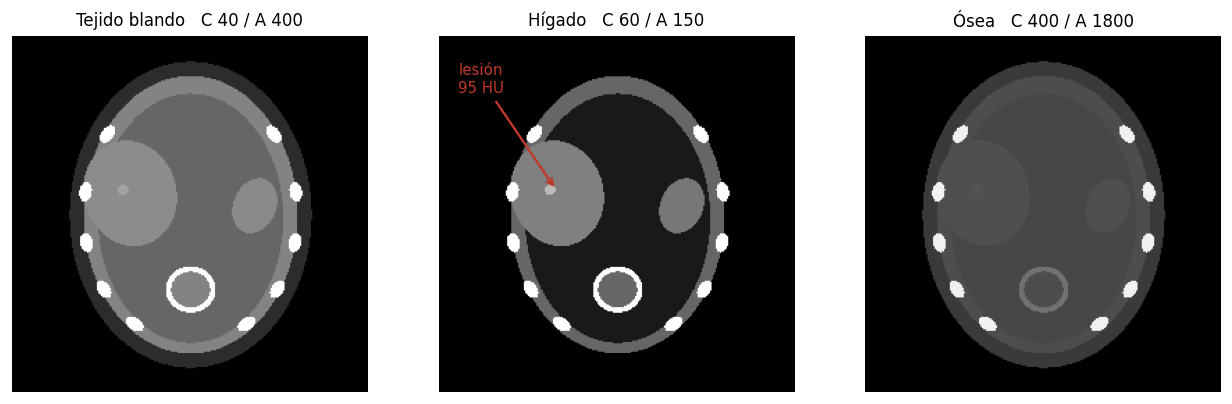

In [3]:
img = abdomen(N, lesion_hu=95)
print(f'rango de la imagen: {img.min():.0f} a {img.max():.0f} HU\n')

fig, axes = plt.subplots(1, 3, figsize=(13, 4.6))
for ax, (c, w, t) in zip(axes, [(40, 400, 'Tejido blando   C 40 / A 400'),
                                (60, 150, 'Hígado   C 60 / A 150'),
                                (400, 1800, 'Ósea   C 400 / A 1800')]):
    ax.imshow(ventana(img, c, w), cmap='gray', vmin=0, vmax=1)
    ax.set_title(t, fontsize=10); ax.axis('off')
axes[1].annotate('lesión\n95 HU', xy=(84, 110), xytext=(30, 40), color=ROJO, fontsize=9,
                 ha='center', arrowprops=dict(arrowstyle='->', color=ROJO, lw=1.4))
plt.show()

La lesion de 95 HU sobre un higado de 60 HU es invisible en ventana de tejido blando y
evidente en ventana de higado. **Los datos son identicos; solo cambia el mapeo a grises.**

De ahi que en radiologia se hable de "ver el estudio en ventana de X". Un hallazgo puede
existir en la matriz de numeros y no aparecer en la pantalla si la ventana esta mal
elegida.

## 3. La transformada de Radon

La transformada de Radon toma una imagen y devuelve todas sus integrales de linea, para
todos los angulos. Es exactamente lo que el tomografo adquiere.

In [4]:
mu = a_mu(img)                                   # HU -> coeficiente de atenuación
angulos = np.linspace(0., 180., 180, endpoint=False)

t0 = time.time()
sino = radon(mu, theta=angulos, circle=False)
print(f'imagen {img.shape} → sinograma {sino.shape} en {time.time()-t0:.1f} s')
print(f'  filas    = posiciones del detector : {sino.shape[0]}')
print(f'  columnas = ángulos de proyección   : {sino.shape[1]}')

p = sino[sino.shape[0]//2, 0]
print(f'\nRayo central a 0°:')
print(f'  ∫μ ds = {p:.2f}')
print(f'  I/I₀ = e^(-∫μ ds) = {np.exp(-p):.4f}')
print(f'  → llega el {100*np.exp(-p):.1f}% de los fotones que entraron')

imagen (256, 256) → sinograma (363, 180) en 0.3 s
  filas    = posiciones del detector : 363
  columnas = ángulos de proyección   : 180

Rayo central a 0°:
  ∫μ ds = 4.46
  I/I₀ = e^(-∫μ ds) = 0.0115
  → llega el 1.2% de los fotones que entraron


Ese ultimo numero explica bastante sobre la tomografia. Por el eje mayor del abdomen
sobrevive apenas el **1.2%** de los fotones. Para que el detector reciba senal util hay que
disparar muchos fotones, y cada foton absorbido deposita energia en el paciente.

Esa es la raiz fisica del compromiso entre calidad de imagen y dosis: no es un problema de
ingenieria que se pueda optimizar hasta desaparecer.

## 4. Por que 180 grados y no 360

La integral de linea de un rayo no cambia si se recorre al reves: proyectar desde 30° y
desde 210° da la misma informacion. Para un haz paralelo, **medio giro basta**, y adquirir
el otro medio solo duplicaria la dosis.

(Los tomografos reales usan haz en abanico y sí giran mas de 180°, pero el principio se
mantiene: la geometria determina cuanta redundancia hay.)

## 5. Leer un sinograma

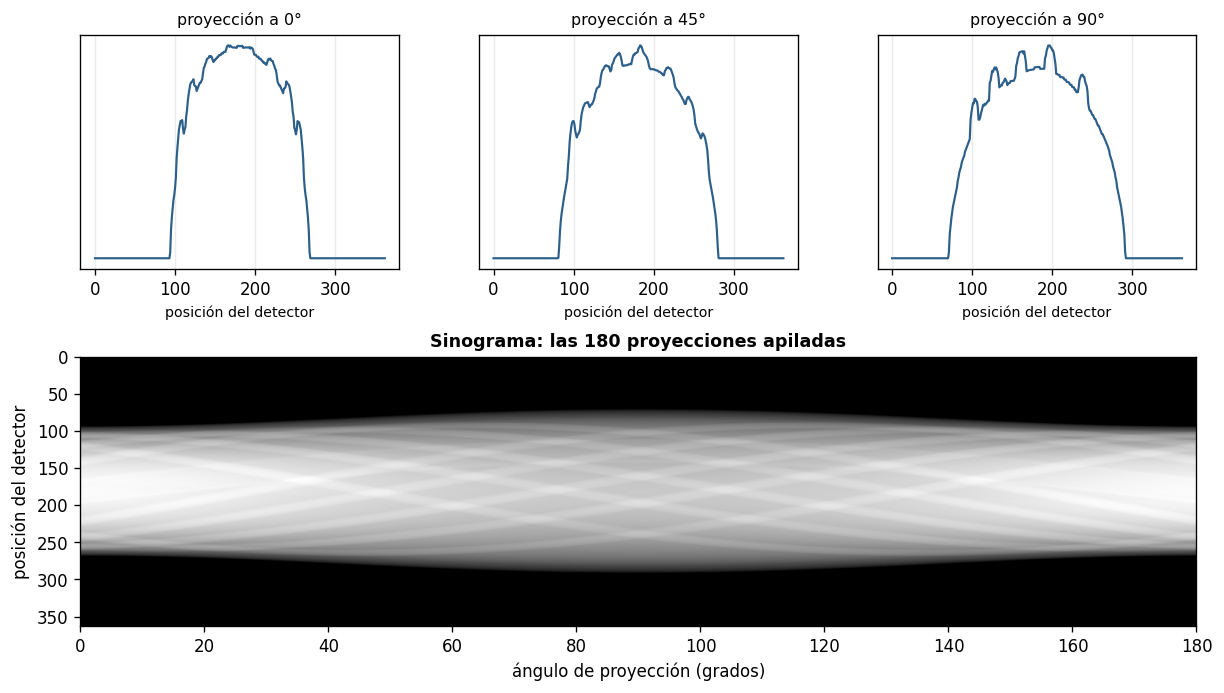

In [5]:
fig = plt.figure(figsize=(12, 6.4))
gs = fig.add_gridspec(2, 3, height_ratios=[1, 1.15], hspace=0.35, wspace=0.25)
for k, a_deg in enumerate((0, 45, 90)):
    ax = fig.add_subplot(gs[0, k])
    ax.plot(radon(mu, theta=[a_deg], circle=False)[:, 0], color=AZUL, lw=1.3)
    ax.set_title(f'proyección a {a_deg}°', fontsize=9.5)
    ax.set_xlabel('posición del detector', fontsize=8.5); ax.set_yticks([]); ax.grid(alpha=0.25)
ax = fig.add_subplot(gs[1, :])
ax.imshow(sino, cmap='gray', aspect='auto', extent=[0, 180, sino.shape[0], 0])
ax.set_xlabel('ángulo de proyección (grados)'); ax.set_ylabel('posición del detector')
ax.set_title('Sinograma: las 180 proyecciones apiladas', fontsize=10.5, fontweight='bold')
plt.show()

Cada columna del sinograma es una proyeccion. Los picos brillantes son las costillas y la
vertebra: donde el rayo atraviesa hueso, la integral de $\mu$ se dispara.

Fijate en la forma: las estructuras trazan curvas onduladas. Eso no es casualidad.

## 6. Por que se llama sinograma

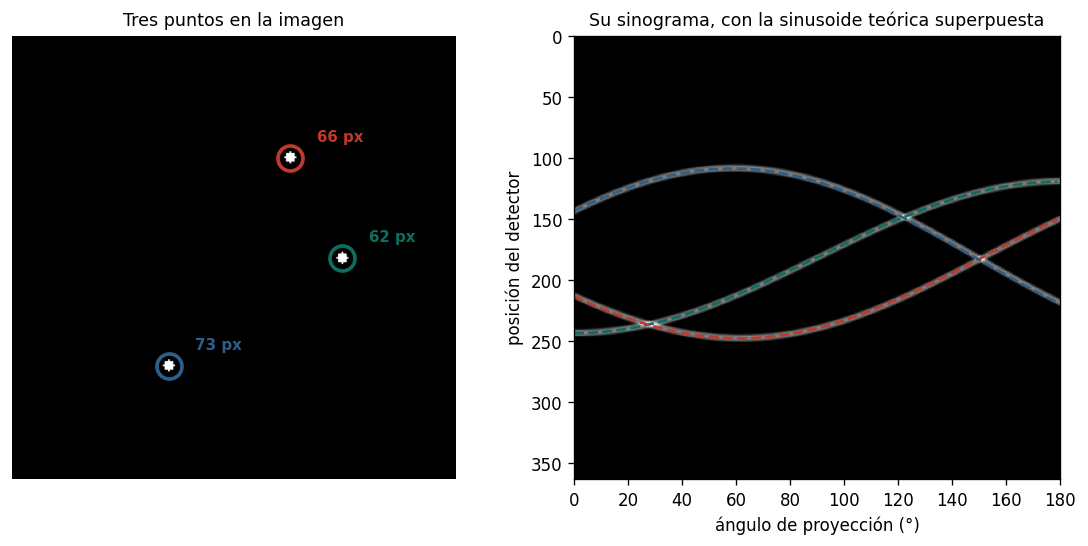

In [6]:
def punto(N, cy, cx, r=3):
    y, x = np.ogrid[:N, :N]
    m = np.zeros((N, N)); m[(y-cy)**2 + (x-cx)**2 <= r*r] = 1.0
    return m


def curva(cy, cx, ang, n_det):
    """Posición del punto en el detector: s(θ) = dx·cos θ − dy·sin θ."""
    t = np.deg2rad(ang); dx = cx - N/2; dy = cy - N/2
    return n_det/2 + dx*np.cos(t) - dy*np.sin(t)


puntos = [(128, 190), (70, 160), (190, 90)]
colores = [VERDE, ROJO, AZUL]
base = sum(punto(N, cy, cx) for cy, cx in puntos)
s_all = radon(base, theta=angulos, circle=False); nd = s_all.shape[0]

fig, axes = plt.subplots(1, 2, figsize=(11.5, 4.8))
axes[0].imshow(base, cmap='gray'); axes[0].axis('off')
axes[0].set_title('Tres puntos en la imagen', fontsize=10.5)
for (cy, cx), c in zip(puntos, colores):
    axes[0].plot(cx, cy, 'o', ms=15, mfc='none', mec=c, mew=2.2)
    axes[0].annotate(f'{np.hypot(cy-N/2, cx-N/2):.0f} px', (cx, cy),
                     textcoords='offset points', xytext=(16, 10), color=c,
                     fontsize=9, fontweight='bold')
axes[1].imshow(s_all, cmap='gray', aspect='auto', extent=[0, 180, nd, 0])
for (cy, cx), c in zip(puntos, colores):
    axes[1].plot(angulos, curva(cy, cx, angulos, nd), color=c, lw=1.6, ls='--')
axes[1].set_xlim(0, 180); axes[1].set_ylim(nd, 0)
axes[1].set_xlabel('ángulo de proyección (°)'); axes[1].set_ylabel('posición del detector')
axes[1].set_title('Su sinograma, con la sinusoide teórica superpuesta', fontsize=10.5)
plt.show()

Un punto a distancia $r$ del centro de rotacion se proyecta en la posicion

$$
s(\theta) = r \cos(\theta - \phi)
$$

una **sinusoide de amplitud $r$**. De ahi el nombre.

Se puede verificar numericamente ajustando la sinusoide por minimos cuadrados:

In [7]:
print(f'{"punto":>14} | {"distancia real":>15} | {"amplitud ajustada":>18} | {"error":>7}')
print('-'*64)
t = np.deg2rad(angulos)
M = np.c_[np.sin(t), np.cos(t), np.ones_like(t)]
for cy, cx in [(128, 128), (128, 190), (70, 160), (190, 90)]:
    s = radon(punto(N, cy, cx), theta=angulos, circle=False)
    d = np.argmax(s, axis=0) - s.shape[0]/2
    A, B, _ = np.linalg.lstsq(M, d, rcond=None)[0]
    amp = np.hypot(A, B); r_real = np.hypot(cy-N/2, cx-N/2)
    print(f'{f"({cy},{cx})":>14} | {r_real:>12.1f} px | {amp:>15.1f} px | {abs(amp-r_real):>6.1f}')

         punto |  distancia real |  amplitud ajustada |   error
----------------------------------------------------------------


     (128,128) |          0.0 px |             0.1 px |    0.1


     (128,190) |         62.0 px |            61.9 px |    0.1


      (70,160) |         66.2 px |            66.3 px |    0.1


      (190,90) |         72.7 px |            72.8 px |    0.0


Error de una decima de pixel. La amplitud de la sinusoide **es** la distancia al centro de
rotacion, y su fase codifica la direccion.

Esto tiene consecuencias practicas. Un radiologo tecnico entrenado detecta problemas
mirando el sinograma antes de reconstruir:

- Una **linea horizontal brillante** que atraviesa todos los angulos: un detector averiado.
- Una **discontinuidad vertical**: el paciente se movio en ese instante.
- Una **sinusoide de amplitud mayor que el campo de vision**: algo fuera del campo esta
  contaminando la adquisicion (un brazo, una via intravenosa).

Y lo mas importante: como cada punto de la imagen se reparte por todo el sinograma,
**cada dato perdido afecta a toda la reconstruccion**, no a una region. Esa es la razon de
que un implante metalico arruine la imagen completa y no solo su vecindad.

## Lo que sigue

Ya tenemos las proyecciones. El problema inverso —recuperar la imagen a partir de ellas—
tiene una solucion ingenua que no funciona, y una correccion sorprendentemente simple que
sí. Ese es el tema del siguiente notebook.

## Donde falla esto

**El modelo es monocromatico.** Un tubo de rayos X real emite un espectro, y los fotones de
menor energia se absorben antes. Eso produce el artefacto de **endurecimiento del haz**:
bandas oscuras entre estructuras densas. Modelarlo requiere simular el espectro completo.

**No hay ruido de fotones.** La deteccion de rayos X es un proceso de Poisson, y con dosis
baja el ruido domina. Se trata en el tercer articulo de esta serie.

**La geometria es de haz paralelo.** Los tomografos modernos usan haz en abanico o cono, y
la reconstruccion cambia (algoritmo de Feldkamp para cono). El haz paralelo es el caso
didactico correcto y la base de todo lo demas.

**El fantoma es una idealizacion.** Los tejidos reales no son homogeneos y los bordes no son
elipses perfectas.

## Referencias

- Radon J. *Über die Bestimmung von Funktionen durch ihre Integralwerte längs gewisser
  Mannigfaltigkeiten.* Berichte Sächsische Akademie der Wissenschaften, 1917.
- Hounsfield G.N. *Computerized transverse axial scanning (tomography).* British Journal of
  Radiology, 1973.
- Kak A.C., Slaney M. *Principles of Computerized Tomographic Imaging.* IEEE Press, 1988.